In [1]:
from project_paths import paths
import polars as pl
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

from src.features import (
    prepare_features,
)

parquet = paths.processed_data / "unified_aims_eir_bgs.parquet"
gpkg = paths.aims_data / "aims.gpkg"

n_blocks = 50
n_splits = 10
seed = 123

In [2]:
from experiments.baseline.baseline import create_arrays

In [3]:


df_feats = prepare_features(pl.read_parquet(parquet))


X, y, cat_idx, asset_ids = create_arrays(df_feats)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)


In [4]:
model = HistGradientBoostingClassifier(
    categorical_features=cat_idx,
    learning_rate=0.05,
    max_iter=400,
    early_stopping=True,
    random_state=seed,
    class_weight="balanced",
)

model.fit(X=X_train, y=y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",400
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.","[0, 1, ...]"
,"early_stopping early_stopping: 'auto' or bool, default='auto'If 'auto', early stopping is enabled if the sample size is larger than10000 or if `X_val` and `y_val` are passed to `fit`. If True, early stoppingis enabled, otherwise early stopping is disabled... versionadded:: 0.23",True
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",123
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form `{class_label: weight}`.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas `n_samples / (n_classes * np.bincount(y))`.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if `sample_weight` is specified... versionadded:: 1.2",'balanced'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Dept

In [6]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print(shap_values)

shap.plots.beeswarm(shap_values)

.values =
array([[[ 4.63581207e-01,  1.01453341e-01, -6.20127740e-01,
         -6.30849092e-01, -2.23535350e-01],
        [-1.85380705e-02, -7.22076805e-02, -1.00865321e-01,
         -5.42479364e-02, -9.77824154e-02],
        [-3.48941791e-02, -8.49509846e-04,  1.00883310e-03,
         -5.40847866e-01, -6.85552609e-03],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 1.70840341e-01, -8.23841584e-02, -6.58317057e-02,
          9.70842769e-02,  1.16033725e-01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00]],

       [[ 8.93352688e-01, -1.52002831e-02, -3.26693915e-01,
         -4.15951168e-01, -9.55406185e-02],
        [ 1.42603388e-01,  3.42726583e-01,  2.81124163e-02,
          8.86720681e-02,  1.94500236e-02],
        [-7.06573098e-02, -5.95035495e-04,  4.83644634e-04,
         -2.68803415e-01, -2.56819641e-03],
        ...,
        [ 0.00000000e+00, 

ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

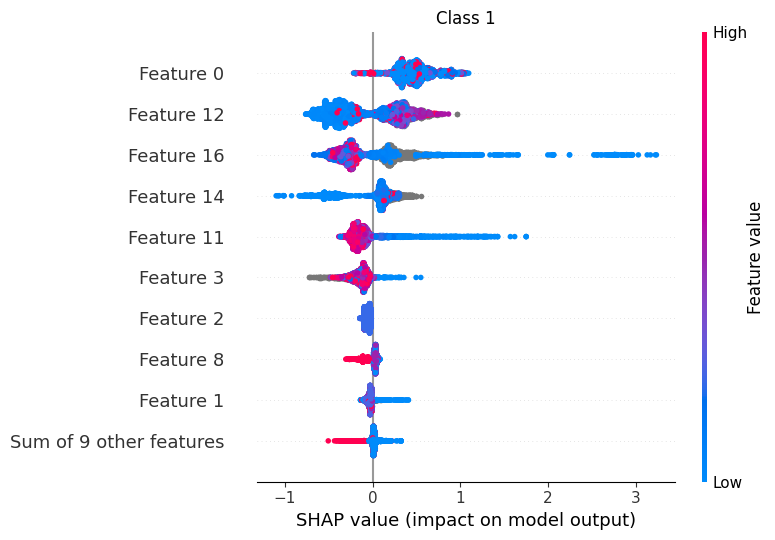

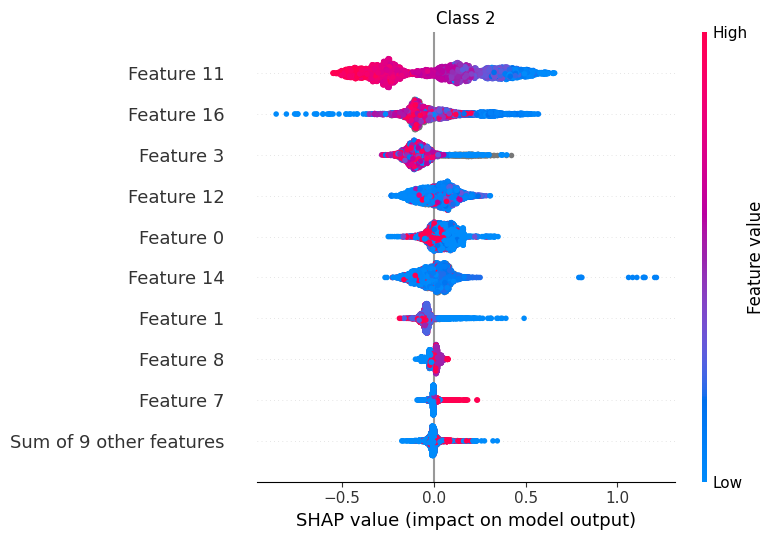

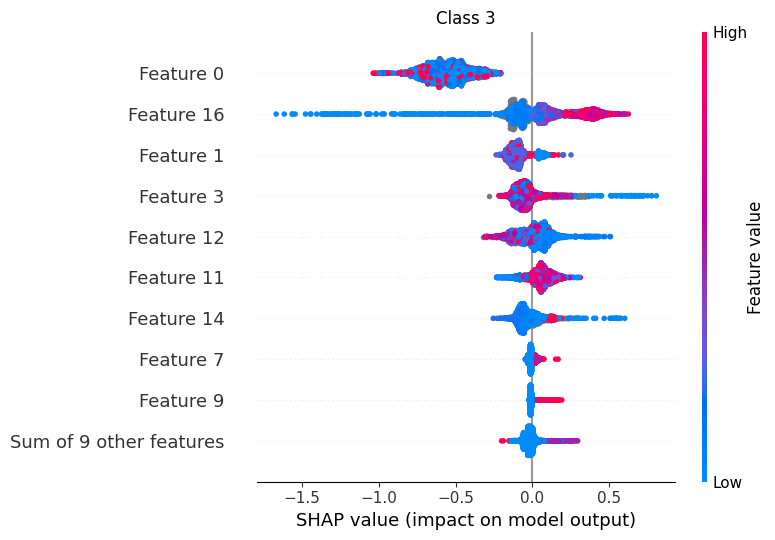

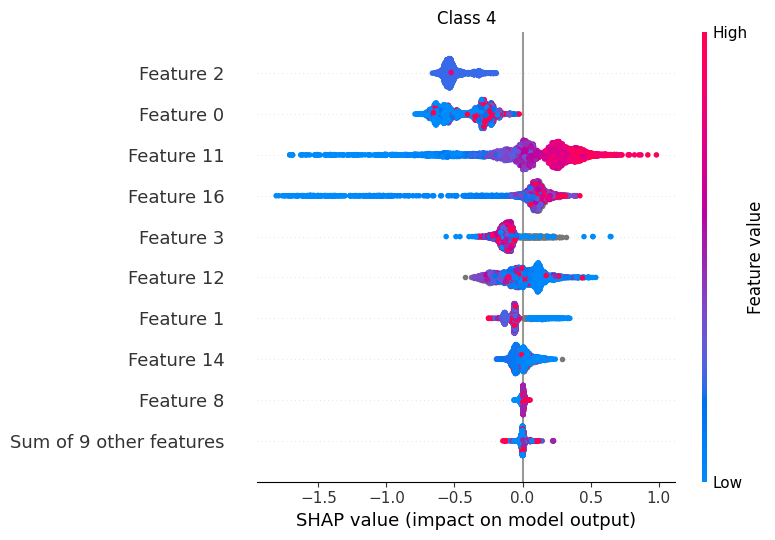

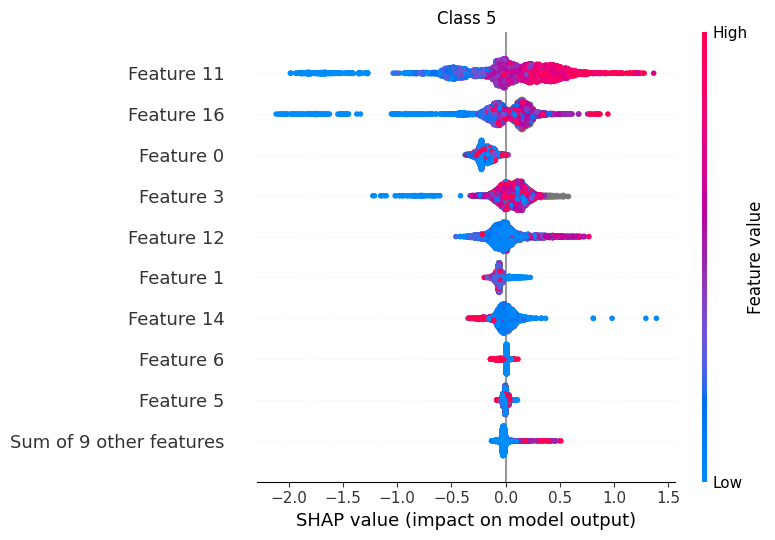

In [7]:
import matplotlib.pyplot as plt

class_names = model.classes_ 

for i, class_name in enumerate(class_names):
    shap.plots.beeswarm(shap_values[:, :, i], show=False)
    plt.title(f"Class {class_name}")
    plt.tight_layout()
    plt.show()

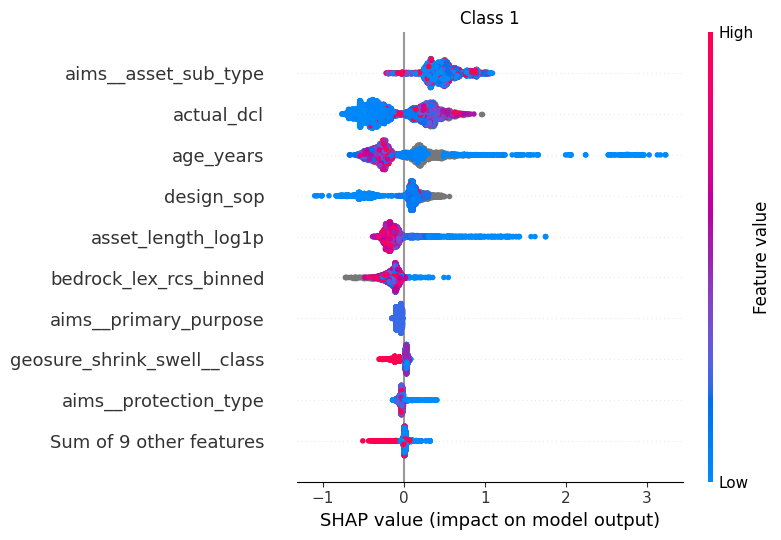

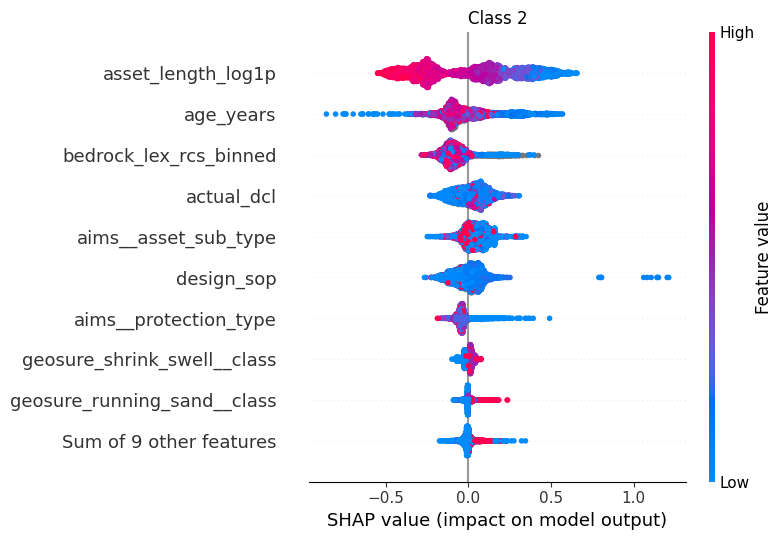

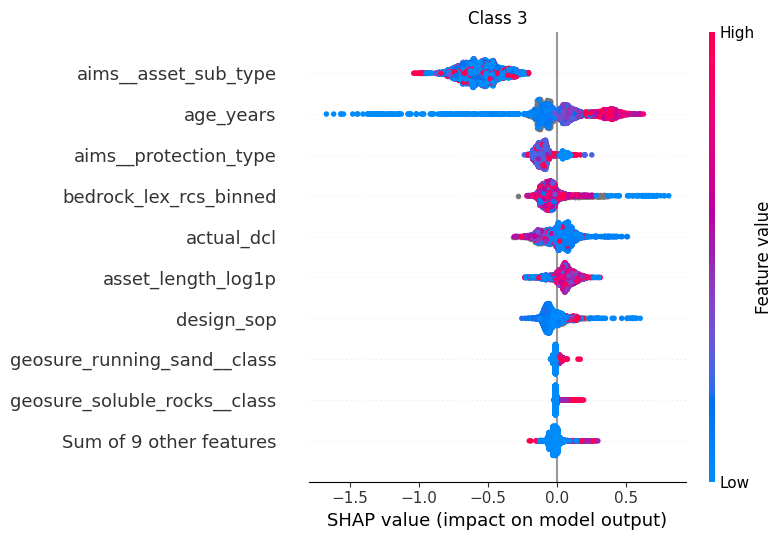

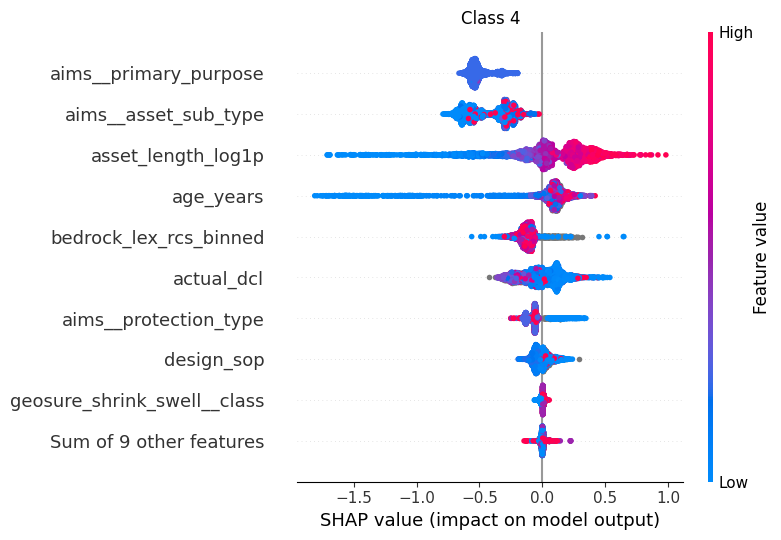

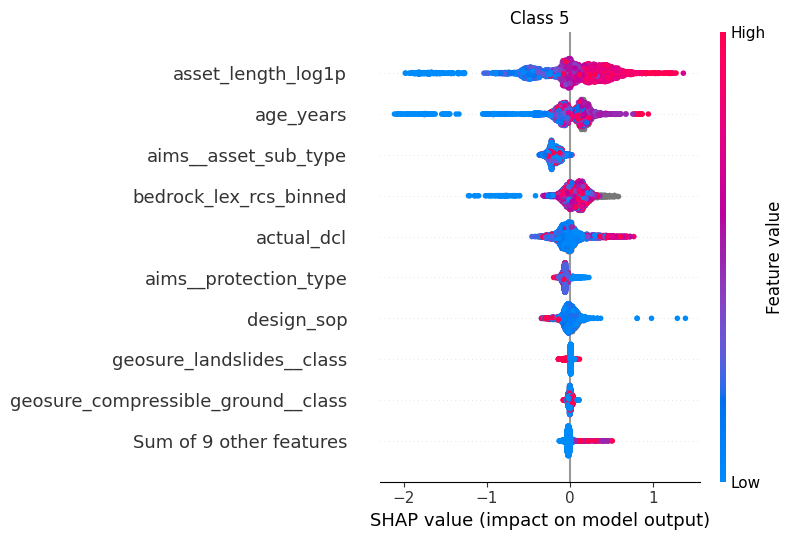

In [9]:
import matplotlib.pyplot as plt

class_names = model.classes_ 

feature_names = feature_cols = [
        col for col in df_feats.columns if col not in ("asset_id", "condition_grade")
    ]

shap_values.feature_names = feature_names

for i, class_name in enumerate(class_names):
    shap.plots.beeswarm(shap_values[:, :, i], show=False)
    plt.title(f"Class {class_name}")
    plt.tight_layout()
    plt.show()